In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, random_split
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import seaborn as sns
from tqdm import tqdm


from sbi.neural_nets import posterior_nn
from sbi.analysis import pairplot
from sbi.inference import NPE, SNPE
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
seed= 555 #55, 33
np.random.seed(seed); 
torch.manual_seed(seed)


/Users/karla/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [3]:
from sbi.analysis import sbc_rank_plot
from sbi.diagnostics import check_sbc, check_tarp, run_sbc, run_tarp
from matplotlib import rcParams
from getdist import plots, MCSamples

num_posterior_samples = 100
num_sbc_samples = 1000
parameter_labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$\theta_4$"]

def plot_pretty(dpi=200, fontsize=12):
    plt.rc("savefig", dpi=dpi)       # dpi resolution of saved image files
    plt.rc('text', usetex=False)      # use LaTeX to process labels
    plt.rc('font', size=fontsize)    # fontsize
    plt.rc('xtick', direction='in')  # make axes ticks point inward
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=10)
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=10)
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [0.5, 1.1]) # fix dotted lines
    return

plot_pretty()

In [4]:
def merge_txt_files(file1_path, file2_path, output_path):
    try:
        with open(file1_path, 'r') as file1, open(file2_path, 'r') as file2:
            content1 = file1.read()
            content2 = file2.read()

        with open(output_path, 'w') as output_file:
            output_file.write(content1)
            output_file.write("\n")  # Optionally add a newline between files
            output_file.write(content2)

        print(f"Files merged successfully into {output_path}")

    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage:
merge_txt_files("all_param_throws.txt", "combined_k2.txt", 'merged_output.txt')

Files merged successfully into merged_output.txt


In [5]:

X1_range = (0,1) #(-15, 15) 0 to 15?
X2_range = (0,1) #(-2, 4)
X3_range = (0,1) #(0, 1)
X4_range = (0,1) #(-0.5, 1)

low = torch.tensor([min(X1_range), min(X2_range), min(X3_range), min(X4_range)])
high = torch.tensor([max(X1_range), max(X2_range), max(X3_range), max(X4_range)])
prior = BoxUniform(low=low, high=high)

# prior = BoxUniform(low=torch.tensor([0.0, 0.0, 0.0, 0.0]),
#                          high=torch.tensor([15.0, 1.0, 1.0, 1.0]))
sample = prior.sample((2,))
print(sample)


tensor([[0.7655, 0.4534, 0.2509, 0.1968],
        [0.7848, 0.0297, 0.7133, 0.8326]])


In [6]:
# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

In [7]:
file='merged_output.txt'
with open(file, mode="r") as file:
    param = list(csv.reader(file))
theta = []
x = []
numbers_ar=[]
for i in range(len(param)):
    numbers = re.findall(r'[-+]?\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+', param[i][0])
    numbers_array = [float(num) for num in numbers]
    numbers_ar.append(numbers_array)
    theta.append(numbers_array[:4])
    x.append(numbers_array[4:62])

print("################### thetas before maping ##########################")
theta1 = [theta[i][0] for i in range(len(theta))]
theta2 = [theta[i][1] for i in range(len(theta))]
theta3 = [theta[i][2] for i in range(len(theta))]
theta4 = [theta[i][3] for i in range(len(theta))]
print("max", max(theta1), max(theta2), max(theta3), max(theta4))
print("min", min(theta1), min(theta2), min(theta3), min(theta4))
print("####################################################################")

theta = torch.tensor(theta, dtype=torch.float32)
theta_or = theta
# theta =( 2 * (theta - theta.min()) / (theta.max() - theta.min()) - 1) #* 5 # Normalize theta to [-1, 1]
theta_min = theta.min(dim=0).values
theta_max = theta.max(dim=0).values
theta = (theta - theta_min) / (theta_max - theta_min)

print(theta[:,0].max(), theta[:,0].min())
print(theta[:,1].max(), theta[:,1].min())
print(theta[:,2].max(), theta[:,2].min())
print(theta[:,3].max(), theta[:,3].min())


theta = torch.tensor(theta[20000:])
theta_test = torch.tensor(theta[:20000])
x = torch.tensor(x[20000:])
x_test = torch.tensor(x[:20000])


print("theta.shape", theta.shape)
print("x.shape", x.shape)
print("theta test.shape", theta_test.shape)
print("x test.shape", x_test.shape)


################### thetas before maping ##########################
max 14.9999 3.99997 0.999996 0.999995
min 7.0869e-05 -8.20886e-05 4.38304e-06 -9.8089e-05
####################################################################
tensor(1.) tensor(0.)
tensor(1.) tensor(0.)
tensor(1.) tensor(0.)
tensor(1.) tensor(0.)


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_17357/2475139209.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta[20000:])
/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_17357/2475139209.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_test = torch.tensor(theta[:20000])


theta.shape torch.Size([195525, 4])
x.shape torch.Size([195525, 58])
theta test.shape torch.Size([20000, 4])
x test.shape torch.Size([20000, 58])


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_17357/2475139209.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x[:20000])


In [8]:
# Custom embedding network for x (58D → 10D)
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim=58, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 45),
            nn.ReLU(),
            nn.Linear(45, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
        )

    def forward(self, x):
        return self.net(x)


In [9]:
embedding_net = EmbeddingNet(input_dim=58, output_dim=24) #16

posterior_nn = posterior_nn(model="maf", embedding_net=embedding_net, hidden_features=55, num_transforms=6) #30, 7

# Subsample (example)
# N = 10000
mask = x.sum(dim=1) < 1e-30  # remove outliers
theta_sub = theta[mask]#[:N]
x_sub = x[mask]#[:N]
x_t = x_sub / x_sub.max()
print(x_t)


print(len(x_t))

inference = NPE(prior=prior, density_estimator=posterior_nn)
density_estimator = inference.append_simulations(theta_sub, x_t).train(
    training_batch_size=256*2,     # smaller batch
    stop_after_epochs=45,
    learning_rate=1e-2,  # 3
    validation_fraction=0.1
)



tensor([[0.0997, 0.1248, 0.0891,  ..., 0.1382, 0.1537, 0.1390],
        [0.0985, 0.1103, 0.1101,  ..., 0.1459, 0.1847, 0.1653],
        [0.0705, 0.0851, 0.0674,  ..., 0.1121, 0.1212, 0.1084],
        ...,
        [0.1180, 0.1638, 0.0989,  ..., 0.1467, 0.1721, 0.1668],
        [0.1452, 0.1604, 0.1546,  ..., 0.2226, 0.2582, 0.2268],
        [0.0841, 0.1026, 0.0834,  ..., 0.1205, 0.1447, 0.1324]])
195405
 Neural network successfully converged after 138 epochs.

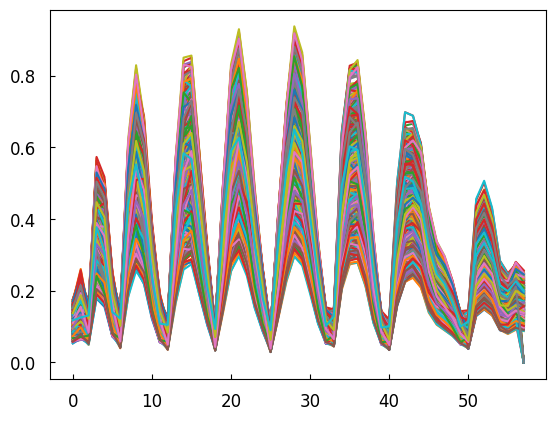

In [10]:
for i in range(1000):
    plt.plot(x_t[i])

In [11]:
posterior = inference.build_posterior(density_estimator)

print(posterior) # prints how the posterior was trained

Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [12]:
mask = x_test.sum(dim=1) < 1e-30  # only keep x with some signal
theta_sub_test = theta_test[mask]
x_sub_test = x_test[mask]
x_t_t = x_sub_test / x_sub_test.max()
log_prob = posterior.log_prob(theta_test[0], x=x_t_t[0])
print(f"log p(θ | x): {log_prob.item():.3f}")

log p(θ | x): 17.045


Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

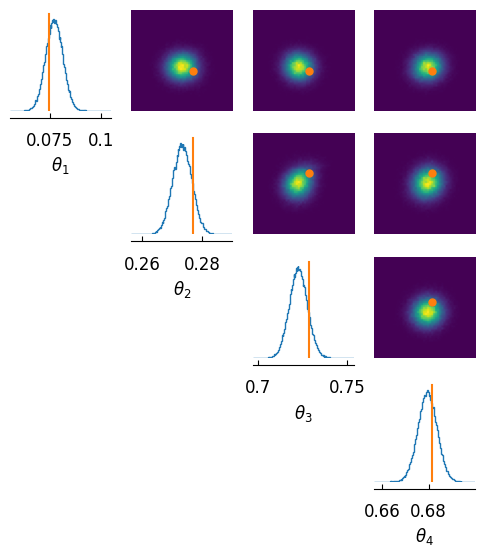

In [13]:
i=0
samples = posterior.sample((100000,), x=x_t_t[i])
pairplot(samples,
         points= theta_sub_test[i].reshape(1,4),
         figsize=(6, 6),
         labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$\theta_4$"]);

In [14]:
import gc

x_observed = torch.tensor(x_t_t, dtype=torch.float32)

def make_summary_statistic_array(x_observed, posterior, test_number = 1000):

  SBI_median_arr = []
  SBI_max_like_arr = []
  SBI_percentile68u_arr = []
  SBI_percentile68l_arr = []
  SBI_percentile95u_arr = []
  SBI_percentile95l_arr = []
  SBI_sample_array = []
  SBI_logp_array = []
  SBI_map_array = []

  for k in range(1):
    # This iterates over multiple SBI networks. If you only have one, len(posterior) should be 1.
    median_arr = []
    max_like_arr = []
    percentile68u_arr = []
    percentile68l_arr = []
    percentile95u_arr = []
    percentile95l_arr = []
    sample_array = []
    logp_array = []
    map_array = []
    for j in range(test_number):
      print(j)
      # This iterates over the number of images in the test set. If you only have one, test_number should be 1.
      median = []
      max_like = []
      percentile68u = []
      percentile68l = []
      percentile95u = []
      percentile95l = []
      samples = posterior.set_default_x(x_observed[j]).sample((1000,))
      # map = posterior[k].map(x=x_observed[j])
      # map_array.append(map.cpu().numpy())
      sample_array.append(samples.cpu())
      logp = posterior.log_prob(samples)
      logp_array.append(logp.cpu())
      argmaxlogp = torch.argmax(posterior.log_prob(samples))
      for i in range(len(samples[0])):
        # This iterates over the number of parameters per image.
        max_like.append(float(samples.cpu()[argmaxlogp][i]))
        median.append(np.median(samples.cpu()[:,i]))
        percentile68l.append(np.percentile(samples.cpu()[:,i],16))
        percentile68u.append(np.percentile(samples.cpu()[:,i],84))
        percentile95l.append(np.percentile(samples.cpu()[:,i],2.5))
        percentile95u.append(np.percentile(samples.cpu()[:,i],97.5))
      median_arr.append(median)
      max_like_arr.append(max_like)
      percentile68l_arr.append(percentile68l)
      percentile68u_arr.append(percentile68u)
      percentile95l_arr.append(percentile95l)
      percentile95u_arr.append(percentile95u)
    SBI_median_arr.append(median_arr)
    SBI_max_like_arr.append(max_like_arr)
    SBI_percentile68u_arr.append(percentile68u_arr)
    SBI_percentile68l_arr.append(percentile68l_arr)
    SBI_percentile95u_arr.append(percentile95u_arr)
    SBI_percentile95l_arr.append(percentile95l_arr)
    SBI_sample_array.append(sample_array)
    SBI_logp_array.append(logp_array)
    # SBI_map_array.append(map_array)

  SBI_median_arr = np.array(SBI_median_arr)
  SBI_max_like_arr = np.array(SBI_max_like_arr)
  SBI_percentile68u_arr = np.array(SBI_percentile68u_arr)
  SBI_percentile68l_arr = np.array(SBI_percentile68l_arr)
  SBI_percentile95u_arr = np.array(SBI_percentile95u_arr)
  SBI_percentile95l_arr = np.array(SBI_percentile95l_arr)
  # SBI_sample_array = np.array(SBI_sample_array)
  SBI_sample_array = SBI_sample_array
  SBI_logp_array = SBI_logp_array
  # SBI_map_array = np.array(SBI_map_array)

  return SBI_sample_array, SBI_logp_array, SBI_map_array, SBI_median_arr, SBI_max_like_arr, SBI_percentile68u_arr, SBI_percentile68l_arr, SBI_percentile95u_arr, SBI_percentile95l_arr

array_dump = make_summary_statistic_array(x_observed, posterior, 1000)

import pickle
file_name = f"4_parameter_npe_summary.pkl"
open_file = open(file_name, "wb")
pickle.dump(array_dump, open_file)
open_file.close()

0


/var/folders/ps/lzncg4g56n9dr7rsdpq6fpzw0000j6/T/ipykernel_17357/2416906237.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_observed = torch.tensor(x_t_t, dtype=torch.float32)


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

1


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

998


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

999


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
SBI_sample_array, SBI_logp_array, SBI_map_array, SBI_best_fit_arr, SBI_max_like_arr, SBI_percentile68u_arr, SBI_percentile68l_arr, SBI_percentile95u_arr, SBI_percentile95l_arr = array_dump
test_number = 1000
prior_low = [min(X1_range), min(X2_range), min(X3_range), min(X4_range)]
prior_high = [max(X1_range), max(X2_range), max(X3_range), max(X4_range)]

limits = np.array([prior_low, prior_high]).T

theta_1 = [theta_sub[:test_number][i][0] for i in range(test_number)]
theta_2 = [theta_sub[:test_number][i][1] for i in range(test_number)]
theta_3 = [theta_sub[:test_number][i][2] for i in range(test_number)]
theta_4 = [theta_sub[:test_number][i][3] for i in range(test_number)]

theta_1, theta_2, theta_3, theta_4 = np.array(theta_1), np.array(theta_2), np.array(theta_3), np.array(theta_4)

print(theta_1.min(), theta_1.max())
print(theta_2.min(), theta_2.max())
print(theta_3.min(), theta_3.max())
print(theta_4.min(), theta_4.max())

true_parameter = np.array([theta_1, theta_2, theta_3, theta_4])

best_fit_t_diff = SBI_best_fit_arr[0,:test_number,:]-true_parameter.T
max_cut = SBI_max_like_arr[0,:test_number,:]-true_parameter.T
max_cut_ext = np.append(max_cut, SBI_max_like_arr[0,:test_number,:],axis=1)

error = SBI_percentile68u_arr[0,:test_number,:] - SBI_percentile68l_arr[0,:test_number,:]

max_cut_norm = max_cut/error
max_cut_ext_norm = np.append(max_cut_norm, SBI_max_like_arr[0,:test_number,:], axis=1)


from getdist import plots, MCSamples
from getdist.styles.tab10 import style_name
plots.set_active_style(style_name)

SBIsamples_plot = MCSamples(
    samples=max_cut_ext, 
    names=[
        r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4',
        r'\theta_1_t', r'\theta_2_t', r'\theta_3_t', r'\theta_4_t'
    ],
    labels=[
        r'\Delta \theta_1', r'\Delta \theta_2', r'\Delta \theta_3', r'\Delta \theta_4',
        r'\Delta \theta_1_t', r'\Delta \theta_2_t', r'\Delta \theta_3_t', r'\Delta \theta_4_t'
    ]
)


0.00245179 0.9990533
8.944874e-05 0.9954526
0.0009828502 0.999545
0.0013275953 0.9978462
Removed no burn in


## Error plot 

In [16]:
SBI_error_1sigma = SBI_percentile68u_arr - SBI_percentile68l_arr
mean_sigma_1_errors = SBI_error_1sigma.mean(axis=1)
print(mean_sigma_1_errors.squeeze())

[0.01051075 0.0090159  0.01621199 0.01125349]


In [17]:
# Returning to original range
# theta_1_or = [i * (theta_max[0] - theta_min[0]) + theta_min[0] for i in theta_1] 
# theta_2_or = [i * (theta_max[1] - theta_min[1]) + theta_min[1] for i in theta_2] 
# theta_3_or = [i * (theta_max[2] - theta_min[2]) + theta_min[2] for i in theta_3] 
# theta_4_or = [i * (theta_max[3] - theta_min[3]) + theta_min[3] for i in theta_4] 

# # print(max(theta_1_or)), print(min(theta_1_or))
# # print("***")
# # print(max(theta_2_or)), print(min(theta_2_or))
# # print("***")
# # print(max(theta_3_or)), print(min(theta_3_or))
# # print("***")
# # print(max(theta_4_or)), print(min(theta_4_or))
# # print("DONE")

# PHYSICS UNITS CONVERSION

# MA = 0.961242  # GeV
# theta_1_p = [MA + (0.03*MA*+i) for i in theta_1_or] # GEV
# theta_2_p  = [1 + (0.5 * i) for i in theta_2_or]
# theta_3_p = [i for i in theta_3_or]
# theta_4_p = [100 - (i * 100) for i in theta_4_or] # %

### Physical Units

In [18]:
MA = 0.961242  # GeV
# theta_max = np.array([15, 4.0, 1.0, 1.0])
# theta_min = np.array([0, -2.0, 0.0, -0.5])
# print(theta_max)
# print(theta_min)
theta_max = np.array([theta_or[:,0].max(), theta_or[:,1].max(), theta_or[:,2].max(), theta_or[:,3].max()])
theta_min = np.array([theta_or[:,0].min(), theta_or[:,1].min(), theta_or[:,2].min(), theta_or[:,3].min()])
print(theta_max)
print(theta_min)

y_normalized = SBI_best_fit_arr.mean(axis=1).squeeze()
yerr_normalized = mean_sigma_1_errors.squeeze()

# Reverse normalization to original range
theta_original = y_normalized * (theta_max - theta_min) + theta_min
theta_errors = yerr_normalized * (theta_max - theta_min)

# Convert to physics units
y_physical = np.array([
    MA * (1 + 0.03 * theta_original[0]),        
    1 + 0.5 * theta_original[1],                
    theta_original[2],                          
    1 - theta_original[3]                       
])

# Error propagation
yerr_physical = np.array([
    MA * 0.03 * theta_errors[0],                
    0.5 * theta_errors[1],                      
    theta_errors[2],                            
    theta_errors[3]                             
])



[14.9999    3.99997   0.999996  0.999995]
[ 7.08690e-05 -8.20886e-05  4.38304e-06 -9.80890e-05]


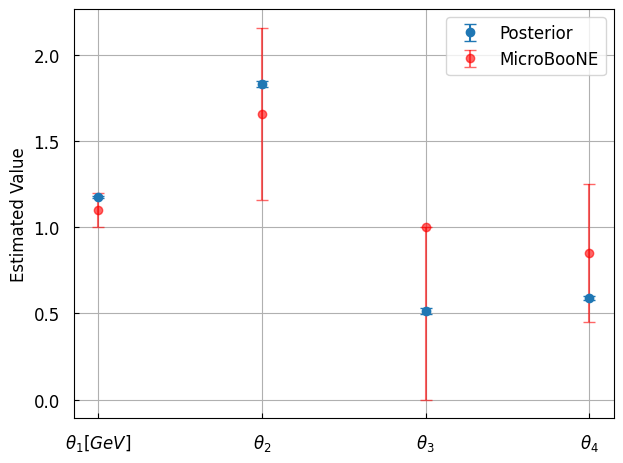

In [19]:
theta_labels = [r'$\theta_1 [GeV]$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$']
x = np.arange(len(theta_labels))

# MicroBooNE physics truth values
reference_y = np.array([1.10, 1.66, 1.0, 0.85])
# 1σ uncertainties
reference_yerr_asym = np.array([
    [0.10, 0.5, 1.0, 0.4],   # lower errors
    [0.10, 0.5, 0.0, 0.4]    # upper errors
])

plt.errorbar(x, y_physical, yerr=yerr_physical, fmt='o', capsize=4, label='Posterior')
plt.errorbar(x, reference_y, yerr=reference_yerr_asym, fmt='o', capsize=4, color='red', label='MicroBooNE', alpha=0.6)

plt.xticks(x, theta_labels)
plt.ylabel('Estimated Value')
# plt.title('Posterior Mean ± 1σ Error (Physical Units)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Posterior_errors_physical_with_truth.pdf", format="pdf", bbox_inches='tight')
plt.show()

### GENIE Units

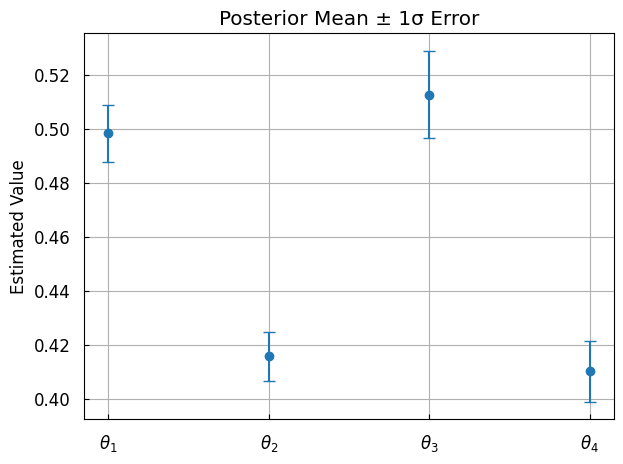

In [20]:
theta_labels = [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$']
x = np.arange(len(theta_labels))
y = SBI_best_fit_arr.mean(axis=1).squeeze()
yerr = mean_sigma_1_errors.squeeze()

plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4)
plt.xticks(x, theta_labels)
plt.ylabel('Estimated Value')
plt.title('Posterior Mean ± 1σ Error')
plt.grid(True)
plt.tight_layout()
plt.savefig("Posterior_errors.pdf", format="pdf", bbox_inches='tight')
plt.show()

## Residuals 

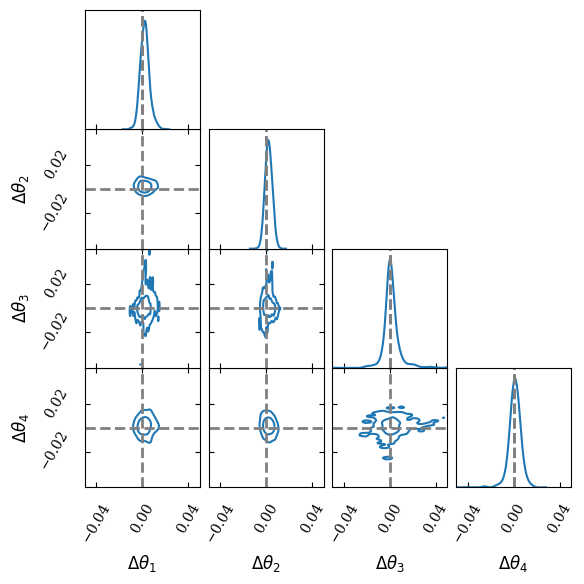

In [21]:
%matplotlib inline
plot_pretty()
rcParams.update({"text.usetex": False})
rcParams['font.family'] = 'serif'

g = plots.get_subplot_plotter(width_inch=6)
g.settings.axes_fontsize=12
g.settings.axis_tick_x_rotation=60
g.settings.axis_tick_y_rotation=60
g.settings.scaling_factor = 1
g.settings.linewidth=2
g.triangle_plot(
    [SBIsamples_plot],
    [r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
    colors=['tab:blue'],
    line_args=[{'color': 'tab:blue', 'lw': 2}],
    contour_lws=[1.5,1.5],
    markers={
        r'\theta_1': 0, r'\theta_2': 0, r'\theta_3': 0, r'\theta_4': 0
    },
    param_limits = {r'\theta_1':[-0.05,0.05],r'\theta_2':[-0.05,0.05],r'\theta_3':[-0.05,0.05],r'\theta_4':[-.05,.05]},
    marker_args={'lw': 2},
    title_limit=0
)
for i in range(len(g.subplots[0,:])):
  g.subplots[i,i].axvline(color='gray', ls='--', lw=2)
plt.savefig('4param_corner_all.pdf',format='pdf')

In [22]:
# # Original normalization bounds
# theta_min = np.array([0, -2.0, 0.0, -0.5])
# theta_max = np.array([15.0, 4.0, 1.0, 1.0])
# MA = 0.961242  # GeV

# # Extract normalized θ samples
# samples_norm = SBIsamples_plot.samples[:, :4] 

# # Return to original range
# theta_orig = samples_norm * (theta_max - theta_min) + theta_min  

# # Map to physical quantities
# MaCCQE_samples = MA + 0.03 * MA * theta_orig[:, 0]
# NormCCMEC_samples = 1 + 0.5 * theta_orig[:, 1]
# XSecShape_CCMEC_samples = theta_orig[:, 2]
# RPA_CCQE_samples = 1 - theta_orig[:, 3]

# # Stack the transformed physical observables
# samples_physical = np.vstack([
#     MaCCQE_samples,
#     NormCCMEC_samples,
#     XSecShape_CCMEC_samples,
#     RPA_CCQE_samples
# ]).T

# # Create a new MCSamples object
# SBIsamples_physical = MCSamples(
#     samples=samples_physical,
#      names=[
#         r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4',
#     ],
#     labels=[
#         r'\Delta \theta_1', r'\Delta \theta_2', r'\Delta \theta_3', r'\Delta \theta_4',
#     ]
# )

# # Plot
# g = plots.get_subplot_plotter(width_inch=6)
# g.settings.axes_fontsize = 12
# g.settings.axis_tick_x_rotation = 60
# g.settings.axis_tick_y_rotation = 60
# g.settings.scaling_factor = 1
# g.settings.linewidth = 2

# g.triangle_plot(
#     [SBIsamples_physical],
#     names=[r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
#     colors=['tab:blue'],
#     line_args=[{'color': 'tab:blue', 'lw': 2}],
#     contour_lws=[1.5, 1.5],
#     markers={
#         r'\theta_1': MA, r'\theta_2': 1, r'\theta_3': 0, r'\theta_4': 1
#     },
#     # param_limits = {r'\theta_1':[-0.05,0.05],r'\theta_2':[-0.05,0.05],r'\theta_3':[-0.05,0.05],r'\theta_4':[-.05,.05]},param_limits=param_limits,
#     marker_args={'lw': 2},
#     title_limit=0
# )
# for i in range(len(g.subplots[0,:])):
#   g.subplots[i,i].axvline(color='gray', ls='--', lw=2)


In [23]:
ranks, dap_samples = run_sbc(theta_sub_test[:1000], x_t_t[:1000], posterior, num_posterior_samples=300)
# check_stats = check_sbc(ranks.cpu(), theta_sub_test.cpu(), dap_samples.cpu(), num_posterior_samples=10)


Drawing 300 posterior samples:   0%|          | 0/300 [00:00<?, ?it/s]

Calculating ranks for 1000 sbc samples.:   0%|          | 0/1000 [00:00<?, ?it/s]

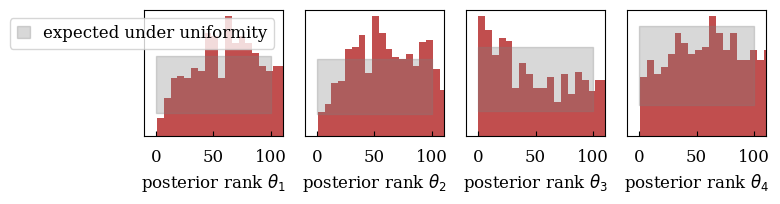

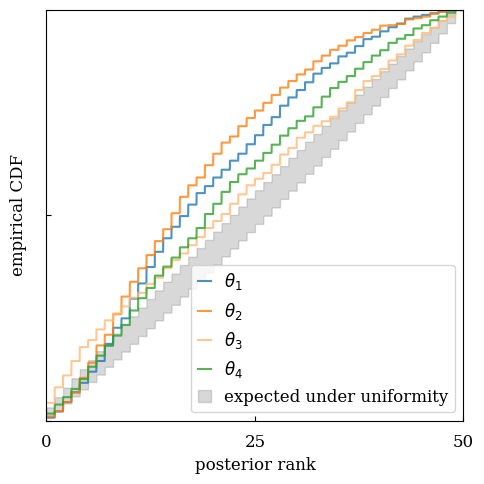

In [24]:
f,ax=sbc_rank_plot(ranks=ranks.cpu(),num_posterior_samples=num_posterior_samples,
             plot_type="hist",
             num_bins=None,parameter_labels=parameter_labels, ranks_labels=[''], figsize = (8,2.2))
plt.tight_layout()
plt.savefig(f'5_param_npe_pos_sbc_hist.pdf', format='pdf')

from cycler import cycler

# These are the "Tableau 20" colors as RGB.
tableau20 = [(31, 119, 180), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (140, 86, 75),
             (227, 119, 194), (23, 190, 207), (158, 218, 229)]

#(174, 199, 232)

# Scale the RGB values to the [0, 1] range, which is the format matplotlib accepts.
for i in range(len(tableau20)):
    r, g, b = tableau20[i]
    tableau20[i] = (r / 255., g / 255., b / 255.)

default_cycler = (cycler(color=tableau20) + cycler(linestyle=['-','-','-','-','-',':',':','--','--','--','--','--']))

plt.rc('lines', linewidth=1.5)
plt.rc('axes', prop_cycle=default_cycler)

f, ax = sbc_rank_plot(ranks.cpu(), 1000, plot_type = "cdf",parameter_labels=parameter_labels, figsize = (5,5))
plt.tight_layout()
plt.savefig(f'5_param_npe_pos__sbc_cdf.pdf', format='pdf')

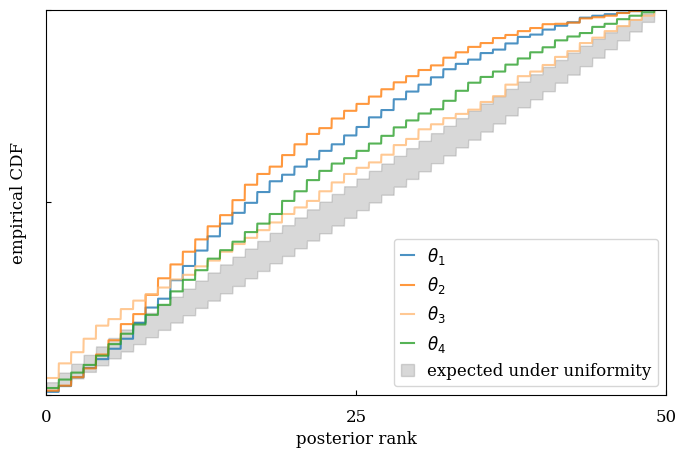

In [25]:
f, ax = sbc_rank_plot(ranks, 10000,  plot_type = "cdf",parameter_labels=parameter_labels)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


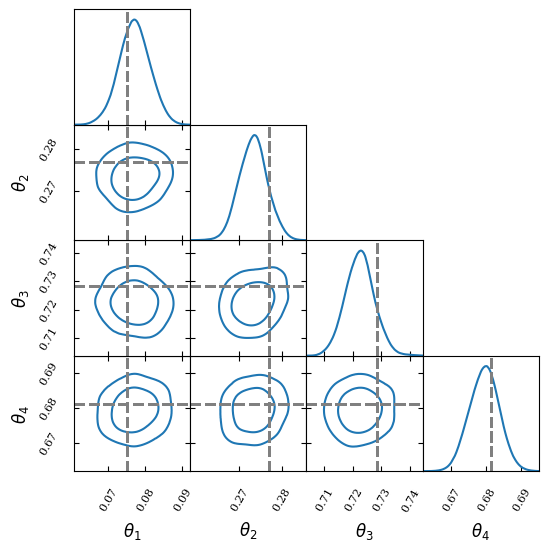

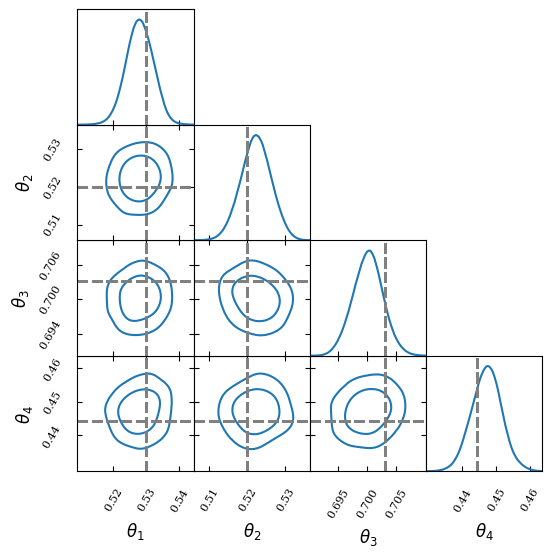

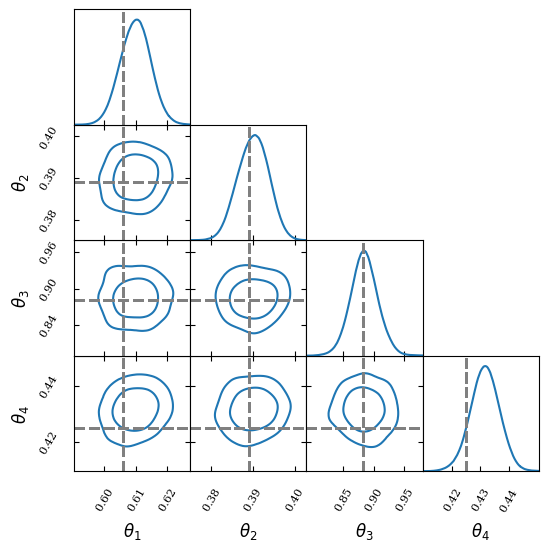

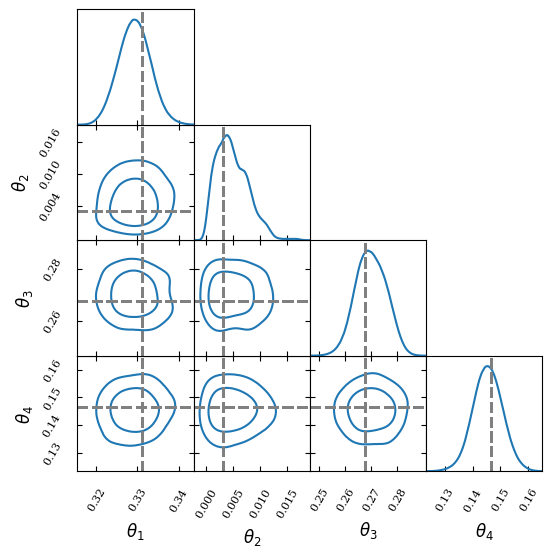

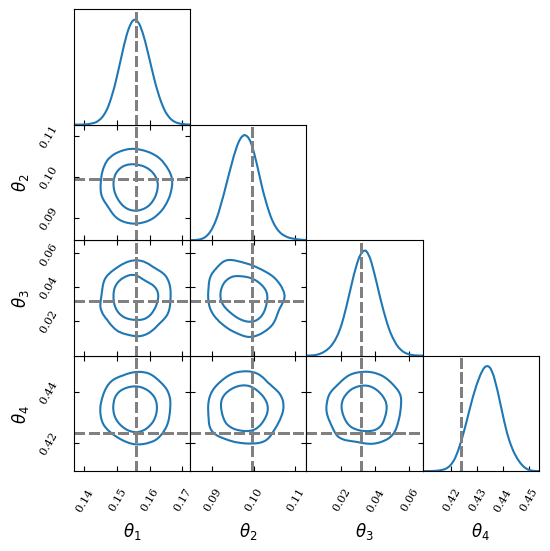

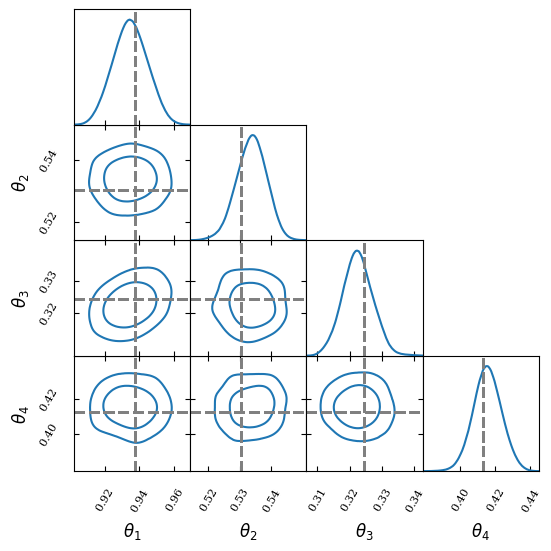

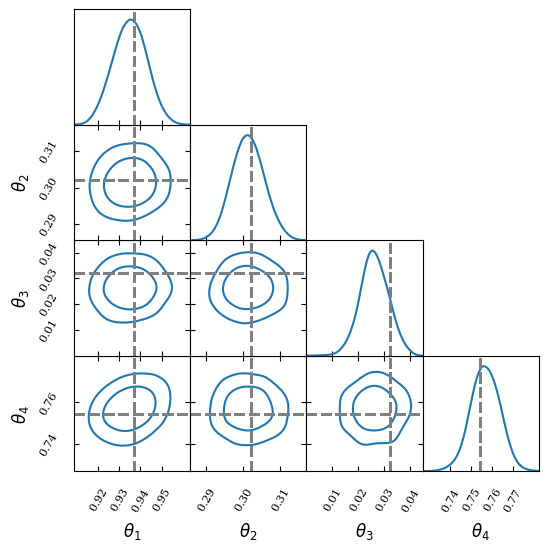

In [26]:
%matplotlib inline
plot_pretty()
rcParams.update({"text.usetex": False})
rcParams['font.family'] = 'serif'

test_number = 1000
prior_low = [min(X1_range), min(X2_range), min(X3_range), min(X4_range)]
prior_high = [max(X1_range), max(X2_range), max(X3_range), max(X4_range)]

limits = np.array([prior_low, prior_high]).T
weird_index = [[0,1,2,3,8,9,10]]

for i, index in enumerate(np.ravel(weird_index[0])):

  theta_1 = [theta_sub[:test_number][index][0] for i in range(test_number)]
  theta_2 = [theta_sub[:test_number][index][1] for i in range(test_number)]
  theta_3 = [theta_sub[:test_number][index][2] for i in range(test_number)]
  theta_4 = [theta_sub[:test_number][index][3] for i in range(test_number)]

  samples = np.array(SBI_sample_array[0][index])
  logp = np.array(SBI_logp_array[0][index])
  # map = np.array(SBI_map_array[0,index])
  best_fit_t = SBI_best_fit_arr[0,index,:]
  max_like_t = SBI_max_like_arr[0,index,:]


  SBIsingle = MCSamples(samples=np.array(samples),
                            names=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\theta_1_t', r'\theta_2_t', r'\theta_3_t', r'\theta_4_t'
                            ],
                            labels=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\Delta \theta_1_t', r'\Delta \theta_2_t', r'\Delta \theta_3_t', r'\Delta \theta_4_t'
                            ])


  g = plots.get_subplot_plotter(width_inch=6)
  g.settings.scaling_factor = 1
  g.settings.axes_fontsize=10
  g.settings.axis_tick_x_rotation=60
  g.settings.axis_tick_y_rotation=60
  g.settings.scaling_factor = 1
  g.settings.title_limit_labels = False
  g.settings.title_limit_fontsize = 10
  g.settings.axis_marker_lw = 2
  g.settings.tight_layout = False
  g.settings.constrained_layout = False
  g.triangle_plot([SBIsingle],[r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
                colors=['tab:blue','tab:orange'],
                contour_lws = [1.5,1.5],
                line_args=[{'color':'tab:blue'},{'color':'tab:orange'}],
                 marker_args ={'lw':2},
                  markers={r'\theta_1':theta_1,r'\theta_2':theta_2, r'\theta_3':theta_3, r'\theta_4':theta_4},
                #   param_limits = {r'\theta_1':[-0,1],r'\theta_2':[-0,1],r'\theta_3':[-0,1],r'\theta_4':[0,1]},
                  title_limit=0)
  plt.savefig('4param_single_image_corner_%s_%s.pdf',format='pdf')

[15.  4.  1.  1.]
[ 0. -2.  0.  0.]
Removed no burn in


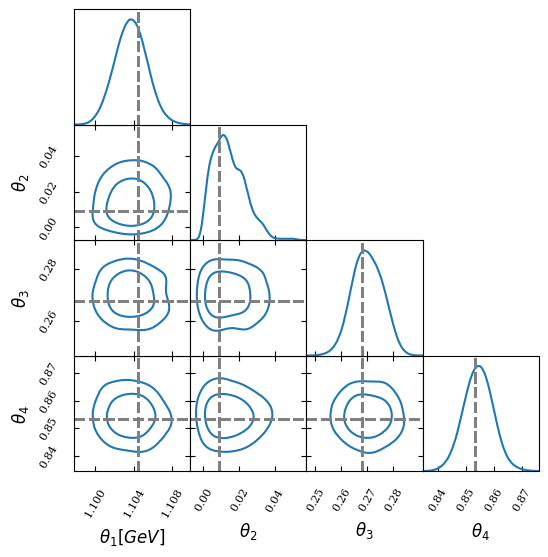

In [27]:
%matplotlib inline
plot_pretty()
rcParams.update({"text.usetex": False})
rcParams['font.family'] = 'serif'

test_number = 1000
prior_low = [min(X1_range), min(X2_range), min(X3_range), min(X4_range)]
prior_high = [max(X1_range), max(X2_range), max(X3_range), max(X4_range)]

limits = np.array([prior_low, prior_high]).T
# weird_index = [[0,1,2,3,8,9,10]]
weird_index = [[3]]

theta_max = np.array([15, 4.0, 1.0, 1.0])
theta_min = np.array([0, -2.0, 0.0, 0])
print(theta_max)
print(theta_min)
# theta_max = np.array([theta_or[:,0].max(), theta_or[:,1].max(), theta_or[:,2].max(), theta_or[:,3].max()])
# theta_min = np.array([theta_or[:,0].min(), theta_or[:,1].min(), theta_or[:,2].min(), theta_or[:,3].min()])
# print(theta_max)
# print(theta_min)
 
for i, index in enumerate(np.ravel(weird_index[0])):

  theta_1 = [theta_sub[:test_number][index][0] for i in range(test_number)]
  theta_1= [i * int((theta_max[0] - theta_min[0])) + theta_min[0] for i in theta_1] # original range
  theta_1= [MA * (1 + 0.03 * i) for i in theta_1]   # Physical units
  theta_2 = [theta_sub[:test_number][index][1] for i in range(test_number)]
  theta_2= [i * int((theta_max[1] - theta_min[1])) + theta_min[1] for i in theta_2]
  theta_2= [1 + 0.5 * i for i in theta_2]
  theta_3 = [theta_sub[:test_number][index][2] for i in range(test_number)]
  theta_3= [i * int((theta_max[2] - theta_min[2])) + theta_min[2] for i in theta_3]
  theta_4 = [theta_sub[:test_number][index][3] for i in range(test_number)]
  theta_4= [i * int((theta_max[3] - theta_min[3])) + theta_min[3] for i in theta_4]
  theta_4= [1 - i for i in theta_4]
  samples = np.array(SBI_sample_array[0][index])

  # Original range
  theta_orig = samples * (theta_max - theta_min) + theta_min  

  # Physical quantities
  MaCCQE_samples = MA + 0.03 * MA * theta_orig[:, 0]
  NormCCMEC_samples = 1 + 0.5 * theta_orig[:, 1]
  XSecShape_CCMEC_samples = theta_orig[:, 2]
  RPA_CCQE_samples = 1 - theta_orig[:, 3]

  # Stack the physical observables
  samples_physical = np.vstack([
      MaCCQE_samples,
      NormCCMEC_samples,
      XSecShape_CCMEC_samples,
      RPA_CCQE_samples
   ]).T


  SBIsingle = MCSamples(samples=np.array(samples_physical),
                            names=[
                                r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\theta_1_t', r'\theta_2_t', r'\theta_3_t', r'\theta_4_t'
                            ],
                            labels=[
                                r'\theta_1[GeV]', r'\theta_2', r'\theta_3', r'\theta_4'#,
                                # r'\Delta \theta_1_t', r'\Delta \theta_2_t', r'\Delta \theta_3_t', r'\Delta \theta_4_t'
                            ])

  # print(theta_1)
  # print(theta_2)
  # print(theta_3)
  # print(theta_4)
  g = plots.get_subplot_plotter(width_inch=6)
  g.settings.scaling_factor = 1
  g.settings.axes_fontsize=10
  g.settings.axis_tick_x_rotation=60
  g.settings.axis_tick_y_rotation=60
  g.settings.scaling_factor = 1
  g.settings.title_limit_labels = False
  g.settings.title_limit_fontsize = 10
  g.settings.axis_marker_lw = 2
  g.settings.tight_layout = False
  g.settings.constrained_layout = False
  g.triangle_plot([SBIsingle],[r'\theta_1', r'\theta_2', r'\theta_3', r'\theta_4'],
                colors=['tab:blue','tab:orange'],
                contour_lws = [1.5,1.5],
                line_args=[{'color':'tab:blue'},{'color':'tab:orange'}],
                 marker_args ={'lw':2},
                  markers={r'\theta_1':theta_1,r'\theta_2':theta_2, r'\theta_3':theta_3, r'\theta_4':theta_4},
                #   param_limits = {r'\theta_1':[-0,1],r'\theta_2':[-0,1],r'\theta_3':[-0,1],r'\theta_4':[0,1]},
                  title_limit=0)
  plt.savefig('4param_single_image_corner.pdf',format='pdf', bbox_inches='tight')

In [28]:
# plt.plot(SBIsingle[0])

In [29]:
def calculate_coverage_fraction(x_observed, pos_list, truth_array, percentile_list, test_number=100, sample_number = 1000):
  count_array = []
  for i in range(test_number):
    samples = pos_list.set_default_x(x_observed[i]).sample((sample_number,),show_progress_bars=False)
    count_vector = []
    for ind, cov in enumerate(percentile_list):
      percentile_l = 50.0 - cov/2
      percentile_u = 50.0 + cov/2
      confidence_l = np.percentile(samples.cpu(),percentile_l,axis=0)
      confidence_u = np.percentile(samples.cpu(),percentile_u,axis=0)
      count = np.logical_and(confidence_u - truth_array.T[i] > 0, truth_array.T[i] - confidence_l > 0)
      count_vector.append(count)
    count_array.append(count_vector)
  count_sum_array = np.sum(count_array, axis=0)
  frac_lens_within_vol = np.array(count_sum_array)
  return np.array(frac_lens_within_vol).T/sample_number

def distance(param_vector, mean_vector, covariance):
  d = np.array(param_vector-mean_vector)
  return d.dot(covariance).dot(d.T)

def calculate_coverage_fraction_distance_2(x_observed, pos_list, truth_array, percentile_list, covariance, test_number=100, sample_number = 1000):
  count_array = []
  for i in range(test_number):
    samples = pos_list.set_default_x(x_observed[i]).sample((sample_number,),show_progress_bars=False).cpu()
    count_vector = []
    mean = np.median(samples, axis=0)
    for ind, percentile in enumerate(percentile_list):
      d = distance(samples, mean, covariance)
      d_true = distance(truth_array[:,i], mean, covariance)
      d_array = d.diagonal()
      # difference = abs(np.array(samples)-mean)
      # difference_true = abs(.T[i]-mean)
      confidence_l = np.percentile(d_array, percentile, axis=0)
      count = confidence_l - d_true > 0
      count_vector.append(count)
    count_array.append(count_vector)
  return np.sum(np.array(count_array), axis=0)/len(samples)

percentile_array = np.linspace(0,100,21)

In [30]:
theta_1 = [theta_sub[:test_number][i][0] for i in range(test_number)]
theta_2 = [theta_sub[:test_number][i][1] for i in range(test_number)]
theta_3 = [theta_sub[:test_number][i][2] for i in range(test_number)]
theta_4 = [theta_sub[:test_number][i][3] for i in range(test_number)]
true_array = np.array([theta_1, theta_2, theta_3, theta_4])
percentile_array = np.linspace(0,100,21)
frac_array = calculate_coverage_fraction(x_t_t, posterior, true_array, percentile_array, test_number)
cov = np.cov(true_array)
frac_array_combined = calculate_coverage_fraction_distance_2(x_observed, posterior, true_array, percentile_array, cov, test_number)


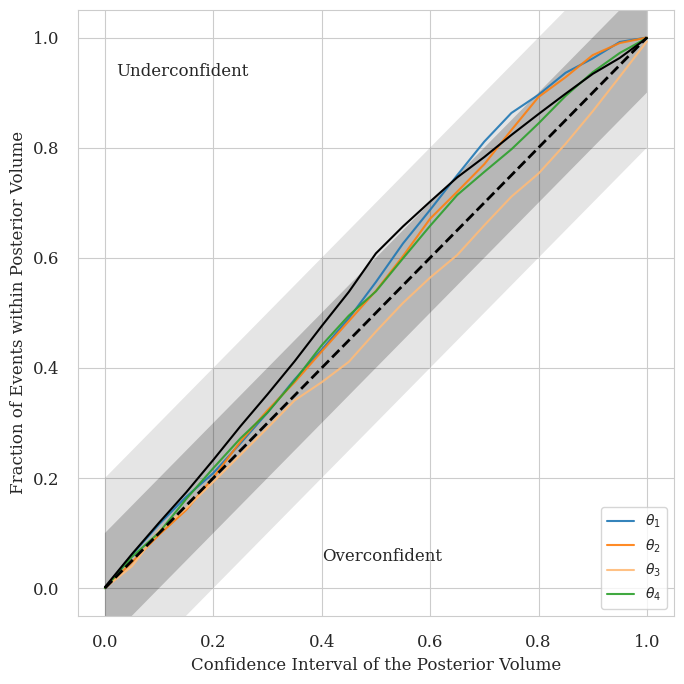

In [31]:
percentile_array = np.linspace(0,100,21)
percentile_array_norm = np.array(percentile_array)/100

from cycler import cycler

# These are the "Tableau 20" colors as RGB.
tableau20 = [(31, 119, 180), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (140, 86, 75),
             (227, 119, 194), (23, 190, 207), (158, 218, 229)]

#(174, 199, 232)

# Scale the RGB values to the [0, 1] range, which is the format matplotlib accepts.
for i in range(len(tableau20)):
    r, g, b = tableau20[i]
    tableau20[i] = (r / 255., g / 255., b / 255.)

default_cycler = (cycler(color=tableau20[:10]) + cycler(linestyle=['-','-','-','-',':',':','--','--','--','--']))

plt.rc('lines', linewidth=1.5)
plt.rc('axes', prop_cycle=default_cycler)

sns.set_style("whitegrid")
rcParams.update({"text.usetex": False})
rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(1,1,figsize=(7,7))
plt.plot(percentile_array_norm, frac_array.T, alpha = .9)
plt.plot(percentile_array_norm, frac_array_combined, c = 'k',ls='-')
plt.plot([0,0.5,1],[0,0.5,1], 'k--', lw=2, zorder=1000)
plt.fill_between(
    x=percentile_array_norm,
    y1=percentile_array_norm-0.1,
    y2=percentile_array_norm+0.1,
    color='k',
    edgecolor="none",
    alpha=0.2,)
plt.fill_between(
    x=percentile_array_norm,
    y1=percentile_array_norm-0.2,
    y2=percentile_array_norm+0.2,
    color='k',
    edgecolor="none",
    alpha=0.1,)
plt.xlim([-0.05,1.05])
plt.ylim([-0.05,1.05])
plt.text(0.02,0.93,'Underconfident', fontsize=12, horizontalalignment='left')
plt.text(0.4,0.05,'Overconfident',fontsize =12, horizontalalignment='left')
plt.legend([r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$'], prop={'size': 10}, ncol=1, loc=4)
plt.xlabel('Confidence Interval of the Posterior Volume')
plt.ylabel('Fraction of Events within Posterior Volume')
# plt.title(f'NPE')
plt.tight_layout()
plt.savefig(f'4_param_npe_pos_v2.pdf', format='pdf')

## Testing with T2K Data

In [32]:
file='my_data_hists_out.txt'
with open(file, mode="r") as file:
    param_t2k = list(csv.reader(file))
x_t2k = []
numbers_ar_t2k=[]
for i in range(len(param_t2k)):
    numbers_t2k = re.findall(r'[-+]?\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+', param_t2k[i][0])
    numbers_array_t2k = [float(num) for num in numbers_t2k]
    numbers_ar_t2k.append(numbers_array_t2k)
    x_t2k.append(numbers_array_t2k)

In [52]:
y_t2k_0 = torch.mean(posterior.sample((1000000,), x=x_t2k[0]), axis=0)
print(y_t2k_0)

Drawing 1000000 posterior samples:   0%|          | 0/1000000 [00:00<?, ?it/s]

tensor([0.9889, 0.8262, 0.8656, 0.9667])


In [53]:
array_dump_t2k = make_summary_statistic_array(x_t2k, posterior, 1000)

SBI_sample_array_t2k, SBI_logp_array_t2k, SBI_map_array_t2k, SBI_best_fit_arr_t2k, \
SBI_max_like_arr_t2k, SBI_percentile68u_arr_t2k, SBI_percentile68l_arr_t2k, \
SBI_percentile95u_arr_t2k, SBI_percentile95l_arr_t2k = array_dump_t2k


0


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

1


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

2


...

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

998


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

999


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

In [54]:
SBI_error_1sigma_t2k = SBI_percentile68u_arr_t2k - SBI_percentile68l_arr_t2k
mean_sigma_1_errors_t2k = SBI_error_1sigma_t2k[0].mean(axis=0)
print(mean_sigma_1_errors_t2k.squeeze())

[0.01473116 0.01827203 0.12463966 0.03495968]


In [65]:
print("Test samples average: ", SBI_best_fit_arr_t2k.mean(axis=1)[0])
print("central value: ", y_t2k_0)

Test samples average:  [0.9897669  0.82620794 0.86752    0.9675468 ]
central value:  tensor([0.9889, 0.8262, 0.8656, 0.9667])


[14.9999    3.99997   0.999996  0.999995]
[ 7.08690e-05 -8.20886e-05  4.38304e-06 -9.80890e-05]
central value GENIE units:  tensor([14.8330,  3.3047,  0.8656,  0.9667])
[1.1  1.66 1.   0.15]


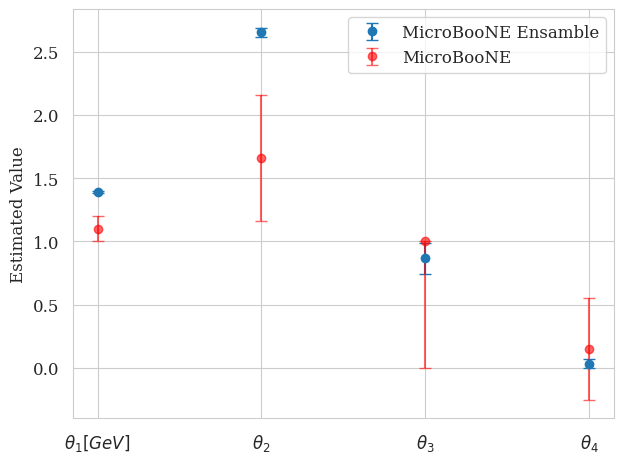

In [66]:
theta_labels = [r'$\theta_1 [GeV]$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$']
x = np.arange(len(theta_labels))

# MicroBooNE physics truth values
reference_y = np.array([1.10, 1.66, 1.0, 0.85])
# 1sigma uncertainties
reference_yerr_asym = np.array([
    [0.10, 0.5, 1.0, 0.4],   # lower errors
    [0.10, 0.5, 0.0, 0.4]    # upper errors
])

# Recovering GENIE units 

theta_max = np.array([theta_or[:,0].max(), theta_or[:,1].max(), theta_or[:,2].max(), theta_or[:,3].max()])
theta_min = np.array([theta_or[:,0].min(), theta_or[:,1].min(), theta_or[:,2].min(), theta_or[:,3].min()])
print(theta_max)
print(theta_min)

y_normalized = y_t2k_0
yerr_normalized = mean_sigma_1_errors_t2k.squeeze()

# Reverse normalization to original range
theta_original = y_normalized * (theta_max - theta_min) + theta_min
print("central value GENIE units: ", theta_original)
theta_errors = yerr_normalized * (theta_max - theta_min)

# Change to physical units

y_physical = np.array([
    MA * (1 + 0.03 * theta_original[0]),        
    1 + (0.5 * theta_original[1]),                
    theta_original[2],                          
    1 - theta_original[3]                       
])

# Error propagation
yerr_physical = np.array([
    MA * 0.03 * theta_errors[0],                
    0.5 * theta_errors[1],                      
    theta_errors[2],                            
    theta_errors[3]                             
])

# Making theta4 red and blue the same units
reference_y[3] = 1-reference_y[3]
print(reference_y) 

plt.errorbar(x, y_physical  , yerr=yerr_physical, fmt='o', capsize=4, label='MicroBooNE Ensamble')
plt.errorbar(x, reference_y, yerr=reference_yerr_asym, fmt='o', capsize=4, color='red', label='MicroBooNE', alpha=0.6)
plt.xticks(x, theta_labels)
plt.ylabel('Estimated Value')
# plt.title('Posterior Mean ± 1σ Error (Physical Units)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Posterior_errors_physical_with_truth.pdf", format="pdf", bbox_inches='tight')
plt.show()